API doc: https://api.usaspending.gov/docs

## First, find the top 10 agencies in spending

In [43]:
import requests
from pprint import pprint

url = "https://api.usaspending.gov/api/v2/search/spending_by_category/awarding_agency/"

payload = {
    "filters": {
        "time_period": [
            {
                "start_date": "2024-10-01",
                "end_date": "2025-09-30"
            }
        ]
    },
    "limit": 10,
    "page": 1
}

response = requests.post(url, json=payload)
data = response.json()
print(response.status_code)
pprint(data)

200
{'category': 'awarding_agency',
 'limit': 10,
 'messages': ['For searches, time period start and end dates are currently '
              'limited to an earliest date of 2007-10-01.  For data going back '
              'to 2000-10-01, use either the Custom Award Download feature on '
              'the website or one of our download or bulk_download API '
              'endpoints as listed on '
              'https://api.usaspending.gov/docs/endpoints. ',
              "'subawards' will be deprecated in the future. Set "
              '‘spending_level’ to ‘subawards’ instead. See documentation for '
              'more information. '],
 'page_metadata': {'hasNext': True,
                   'hasPrevious': False,
                   'next': 2,
                   'page': 1,
                   'previous': None},
 'results': [{'agency_slug': 'department-of-health-and-human-services',
              'amount': 2024160089401.46,
              'code': 'HHS',
              'id': 806,
          

In [44]:
# check dictionary keys
print(type(data))
data.keys()

<class 'dict'>


dict_keys(['category', 'spending_level', 'limit', 'page_metadata', 'results', 'messages'])

In [45]:
# top 10 results
results = data["results"]

# check names and amounts of the top 10 agencies' spending
top10 = [[agency['name'], agency['amount']] for agency in results]
top10

[['Department of Health and Human Services', 2024160089401.46],
 ['Social Security Administration', 1634789118456.8],
 ['Department of Defense', 501261240107.32],
 ['Department of Veterans Affairs', 287951820417.74],
 ['Department of Agriculture', 185341898408.05],
 ['Department of Transportation', 134880545909.74],
 ['Department of Education', 96020148227.14],
 ['Department of Energy', 81298569640.42],
 ['Department of Housing and Urban Development', 77735556226.34],
 ['Department of Homeland Security', 73319086394.74]]

In [46]:
# names of the ten agencies
agencies = [agency[0] for agency in top10]
print(agencies)

['Department of Health and Human Services', 'Social Security Administration', 'Department of Defense', 'Department of Veterans Affairs', 'Department of Agriculture', 'Department of Transportation', 'Department of Education', 'Department of Energy', 'Department of Housing and Urban Development', 'Department of Homeland Security']


## Second, find spending over time

In [47]:
import pandas as pd

url = "https://api.usaspending.gov/api/v2/search/spending_over_time/"

# setup a template with value to the agencies key vacant
base_payload = {
    "group": "month",
    "filters": {
        "time_period": [
            {
                "start_date": "2014-10-01",
                "end_date": "2025-09-30"
            }
        ],
        "agencies": []
    }
}

# setup a vacant list to store returned data
all_data = []

# ues for-loop to send API calls to the ten agencies
for agency in agencies:

    payload = base_payload.copy()  
    
    payload["filters"]["agencies"] = [{
        "type": "awarding",
        "tier": "toptier",
        "name": agency
    }]
    
    response = requests.post(url, json=payload)
    data = response.json()

    # use another for-loop to extract each row of ten different data from the ten agencies; each extraction in pre-setcup a dictionary form is appended to all_data list
    for row in data["results"]:
        all_data.append({
    "agency": agency,
    "fiscal_year": int(row["time_period"]["fiscal_year"]),
    "month": int(row["time_period"]["month"]),
    "spending": row["aggregated_amount"]
    })

df = pd.DataFrame(all_data)
df

,agency,fiscal_year,month,spending
0,Department of Health and Human Services,2015,1,9.404651e+10
1,Department of Health and Human Services,2015,2,2.698805e+09
2,Department of Health and Human Services,2015,3,1.629692e+11
3,Department of Health and Human Services,2015,4,1.068669e+11
4,Department of Health and Human Services,2015,5,4.146564e+09
...,...,...,...,...
1315,Department of Homeland Security,2025,8,2.520574e+09
1316,Department of Homeland Security,2025,9,1.034520e+09
1317,Department of Homeland Security,2025,10,1.562123e+09
1318,Department of Homeland Security,2025,11,3.184627e+09


In [48]:
# translate fiscal date to calender date
# FY starts on October 1st, ends on September 30th.

# make sure it is integer before translation
df["fiscal_year"] = df["fiscal_year"].astype(int)
df["month"] = df["month"].astype(int)

# create calendar month column
df["calendar_month"] = ((df["month"] + 8) % 12) + 1

# create calendar year column
df["calendar_year"] = df["fiscal_year"]
df.loc[df["month"] <= 3, "calendar_year"] = df["fiscal_year"] - 1       # df.loc[condition, column] = value ——> override the value in the column that meets the condition to a new value

df

,agency,fiscal_year,month,spending,calendar_month,calendar_year
0,Department of Health and Human Services,2015,1,9.404651e+10,10,2014
1,Department of Health and Human Services,2015,2,2.698805e+09,11,2014
2,Department of Health and Human Services,2015,3,1.629692e+11,12,2014
3,Department of Health and Human Services,2015,4,1.068669e+11,1,2015
4,Department of Health and Human Services,2015,5,4.146564e+09,2,2015
...,...,...,...,...,...,...
1315,Department of Homeland Security,2025,8,2.520574e+09,5,2025
1316,Department of Homeland Security,2025,9,1.034520e+09,6,2025
1317,Department of Homeland Security,2025,10,1.562123e+09,7,2025
1318,Department of Homeland Security,2025,11,3.184627e+09,8,2025


In [ ]:
# modify properties to ISO datetime to be used in Altair or matplotlib
df["date"] = pd.to_datetime(
    df["calendar_year"].astype(str) + "-" +
    df["calendar_month"].astype(str).str.zfill(2)       # .zfill() is a function that pads the left side of a string with zeros to match the number of digits: (JAN) 1 —> 01 
)

df

,agency,fiscal_year,month,spending,calendar_month,calendar_year,date
0,Department of Health and Human Services,2015,1,9.404651e+10,10,2014,2014-10-01
1,Department of Health and Human Services,2015,2,2.698805e+09,11,2014,2014-11-01
2,Department of Health and Human Services,2015,3,1.629692e+11,12,2014,2014-12-01
3,Department of Health and Human Services,2015,4,1.068669e+11,1,2015,2015-01-01
4,Department of Health and Human Services,2015,5,4.146564e+09,2,2015,2015-02-01
...,...,...,...,...,...,...,...
1315,Department of Homeland Security,2025,8,2.520574e+09,5,2025,2025-05-01
1316,Department of Homeland Security,2025,9,1.034520e+09,6,2025,2025-06-01
1317,Department of Homeland Security,2025,10,1.562123e+09,7,2025,2025-07-01
1318,Department of Homeland Security,2025,11,3.184627e+09,8,2025,2025-08-01


# Third, plot it

In [50]:
import altair as alt

chart = alt.Chart(df).mark_line().encode(
    x=alt.X("date:T", title="Date"),
    y=alt.Y("spending:Q", title="Spending"),
    color=alt.Color("agency:N", title="Agency")
)

chart.properties(
    width=700,  # unit = pixel
    height=400
)

alt.Chart(...)

In [51]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [52]:
%%R
library(tidyverse)

# scale down the spending by dividing it by one million
data <- read.csv('spending.csv')
data <- data |>
  mutate(spending = spending / 100000000)

data

                                          agency fiscal_year month     spending
1        Department of Health and Human Services        2015     1  940.4651478
2        Department of Health and Human Services        2015     2   26.9880456
3        Department of Health and Human Services        2015     3 1629.6918395
4        Department of Health and Human Services        2015     4 1068.6685581
5        Department of Health and Human Services        2015     5   41.4656437
6        Department of Health and Human Services        2015     6 1617.4709239
7        Department of Health and Human Services        2015     7  857.9431199
8        Department of Health and Human Services        2015     8   35.4379251
9        Department of Health and Human Services        2015     9 1704.1483563
10       Department of Health and Human Services        2015    10  819.5617070
11       Department of Health and Human Services        2015    11   57.9532414
12       Department of Health and Human 

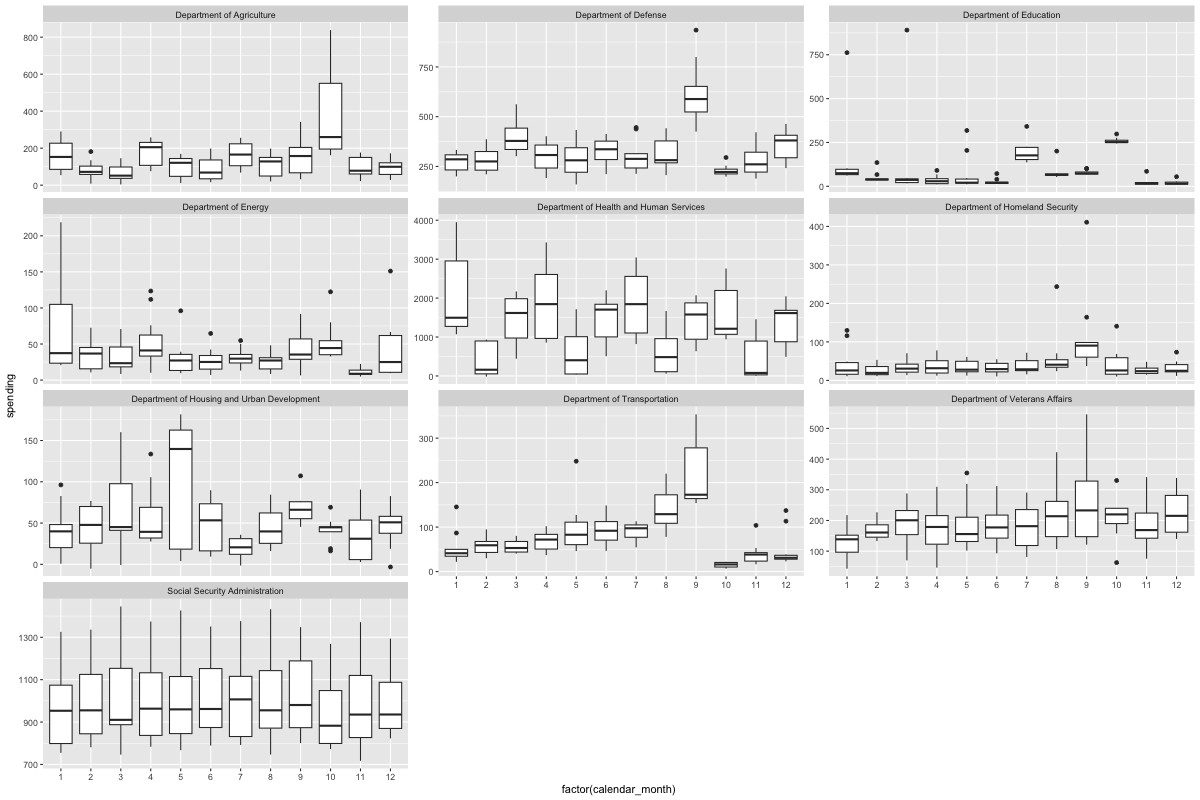

In [53]:
%%R -w 1200 -h 800
library(tidyverse)

chart <- ggplot(data, aes(x = factor(calendar_month), y = spending)) +
  geom_boxplot() +
  facet_wrap(~ agency, scales = "free_y", ncol = 3) 

chart

## Interpretation
- agriculture: tendency to spend big in september, but no outliers - kinda sus
- defense : remarkable outlier in september - sus
- education: a bigger spending in september but widespread outliers so nothing suspicious?
- energy: outlier in september but seemingly unsus
- health and human : normal
- homeland security: regular box height but huge outliers - super sus
- housing and urban development : bit of outlier in september bus unsus
- transportation: tendency to have a bigger spending in september without outliers - kinda sus?
- veterans affaris: unsus
- social security admin: super unsus

### now I'm wondering if there is any distinction between years of administration, like biden admin (2021~2024) vs trump admin (2016~2020, 2025~) vs obama (~2015) 

In [54]:
%%R

data <- data |>
  mutate(
    administration = case_when(
      calendar_year <= 2016 ~ "Obama / transition",
      calendar_year >= 2017 & calendar_year <= 2020 ~ "Trump 1",
      calendar_year >= 2021 & calendar_year <= 2024 ~ "Biden",
      calendar_year >= 2025 ~ "Trump 2"
    )
  )

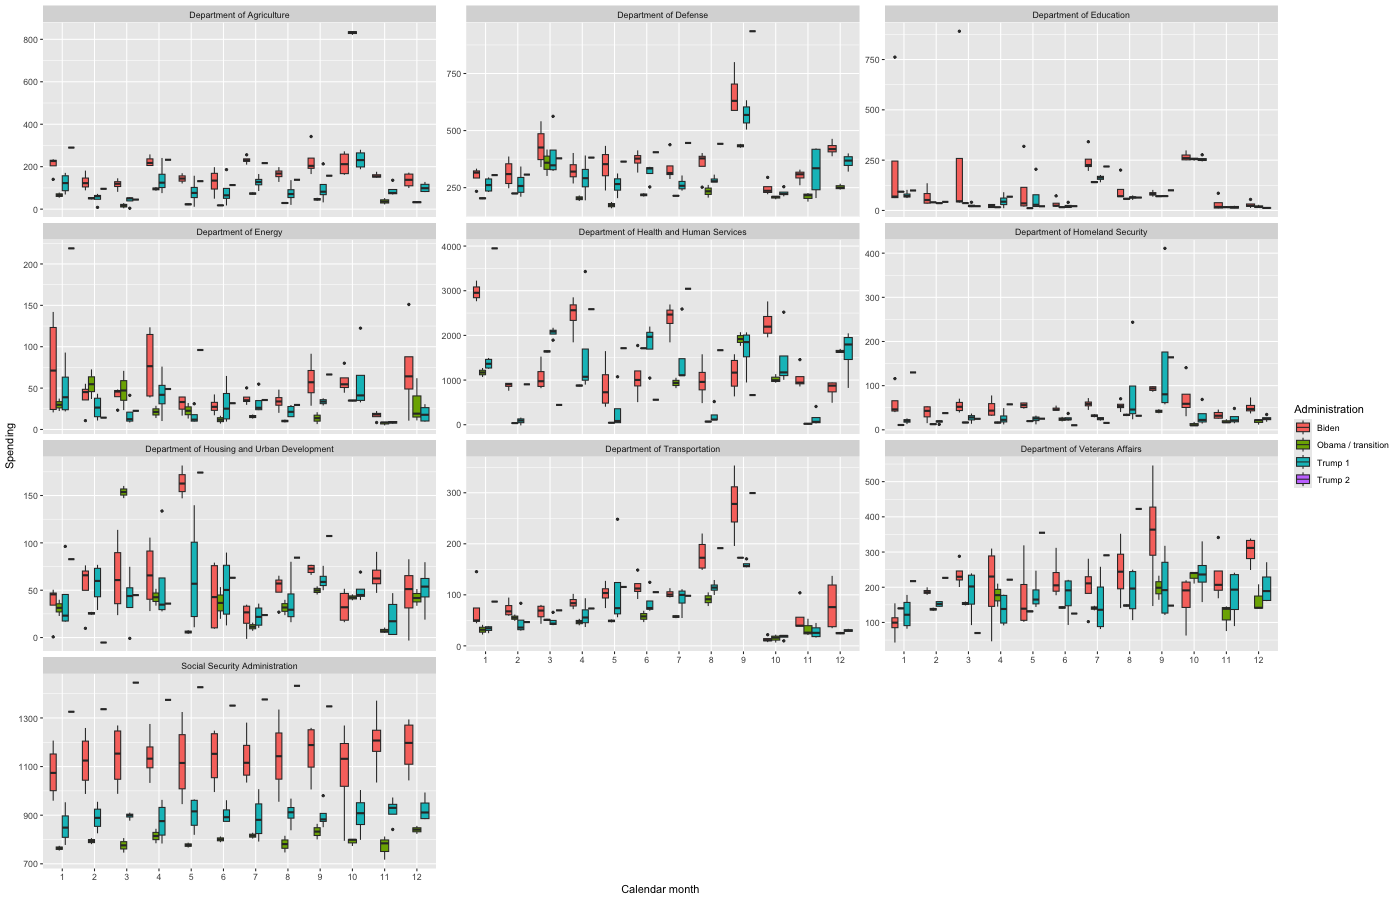

In [55]:
%%R -w 1400 -h 900

chart_admin <- ggplot(
  data,
  aes(x = factor(calendar_month), y = spending, fill = administration)
) +
  geom_boxplot(position = position_dodge(width = 0.75), outlier.size = 0.8) +
  facet_wrap(~ agency, scales = "free_y", ncol = 3) +
  labs(
    x = "Calendar month",
    y = "Spending",
    fill = "Administration"
  )

chart_admin

## Heatmap by agency using z-score and mean

In [56]:
%%R

# rename the name column to fiscal_month for clarity
names(data)
colnames(data)[3] <- "fiscal_month"

names(data)

[1] "agency"         "fiscal_year"    "fiscal_month"   "spending"      
[5] "calendar_month" "calendar_year"  "administration"


In [ ]:
%%R 

tail(data, 5)

                              agency fiscal_year fiscal_month  spending
1316 Department of Homeland Security        2025            8  25.20574
1317 Department of Homeland Security        2025            9  10.34520
1318 Department of Homeland Security        2025           10  15.62123
1319 Department of Homeland Security        2025           11  31.84627
1320 Department of Homeland Security        2025           12 164.08591
     calendar_month calendar_year administration
1316              5          2025        Trump 2
1317              6          2025        Trump 2
1318              7          2025        Trump 2
1319              8          2025        Trump 2
1320              9          2025        Trump 2


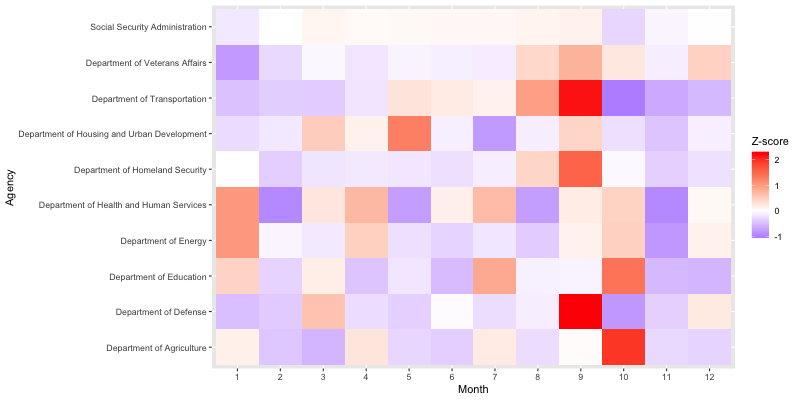

In [69]:
%%R -w 800 -h 400

# create a dataframe called data_heat_z to plot a heatmap with z score
# summarise() claculates summary statistics by group and reconstruct the dataframe to display one row per group; without group, it summarizes the whole into one row.
data_heat_z <- data |>
  group_by(agency) |>
  mutate(zscore = (spending - mean(spending)) / sd(spending)) |>      # calcuate z-score by agency
  group_by(agency, calendar_month) |>                                 # group by a combination : agency + calendar_month ——> this comb has multiple years of observation, for example, DOD-Sep-(2020)-zscore, DOD-Sep-(2021)-zscore, and so on.
  summarise(mean_z = mean(zscore, na.rm = TRUE), .groups = "drop")    # cacluate a mean of z-score by the combination (agency + calendar_month); summarise() reduces the number of rows to the number of groups. in this case, each agency has 12 rows(months) so it's reduced to 12X10 = 120; na.rm = TRUE means ReMove NAn if any; .groups = "drop" means ungrouping, making it back in a regular dataframe form. 

ggplot(data_heat_z, aes(
  x = factor(calendar_month),
  y = agency,
  fill = mean_z
)) +
  geom_tile() +
  scale_fill_gradient2(low = "blue", mid = "white", high = "red", midpoint = 0) +
  labs(
    x = "Month",
    y = "Agency",
    fill = "Z-score"
  )

## Heatmap by agency using z-score and median
median should work better in this case since many outliers are observed

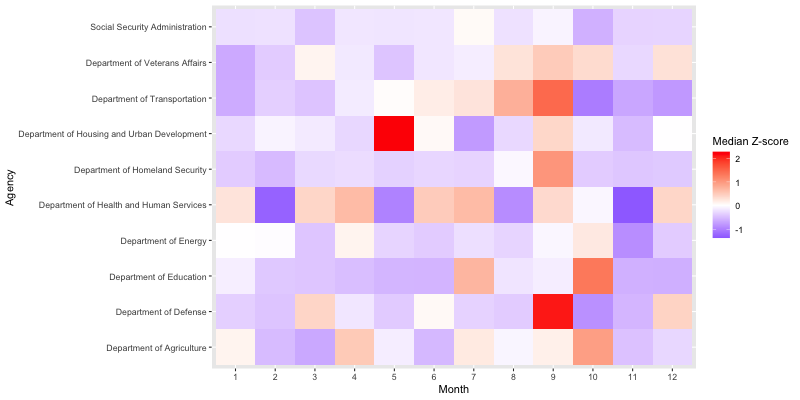

In [68]:
%%R -w 800 -h 400
data_heat_z <- data |>
  group_by(agency) |>
  mutate(zscore = (spending - mean(spending)) / sd(spending)) |>
  group_by(agency, calendar_month) |>
  summarise(median_z = median(zscore, na.rm = TRUE), .groups = "drop")

ggplot(data_heat_z, aes(
  x = factor(calendar_month),
  y = agency,
  fill = median_z
)) +
  geom_tile() +
  scale_fill_gradient2(
    low = "blue",
    mid = "white",
    high = "red",
    midpoint = 0,
    # limits = c(-3, 3)
  ) +
  labs(
    x = "Month",
    y = "Agency",
    fill = "Median Z-score"
  )

# Fourth, compare September's spending to the rest's by year by agency

In [ ]:
%%R

# create a dataframe to compare September to the other months
sept_compare <- data |>
  filter(
    agency %in% c(                              # %in% is a boolean ——> agency == "Defense" OR agency == "Transportation"
      "Department of Defense",
      "Department of Homeland Security",
      "Department of Transportation"
    )
  ) |>
  group_by(agency, fiscal_year) |>
  summarise(
    september_spending = sum(spending[fiscal_month == 12], na.rm = TRUE),
    other_months_total = sum(spending[fiscal_month != 12], na.rm = TRUE),
    other_months_avg = mean(spending[fiscal_month != 12], na.rm = TRUE),
    ratio = september_spending / other_months_avg,
    .groups = "drop"
  )

sept_compare

# A tibble: 33 × 6
   agency     fiscal_year september_spending other_months_total other_months_avg
   <chr>            <int>              <dbl>              <dbl>            <dbl>
 1 Departmen…        2015               425.              2377.             216.
 2 Departmen…        2016               442.              2606.             237.
 3 Departmen…        2017               504.              2775.             252.
 4 Departmen…        2018               633.              3027.             275.
 5 Departmen…        2019               594.              3318.             302.
 6 Departmen…        2020               543.              3775.             343.
 7 Departmen…        2021               588.              3365.             306.
 8 Departmen…        2022               589.              3656.             332.
 9 Departmen…        2023               672.              4000.             364.
10 Departmen…        2024               800.              3767.             342.
# ℹ 23 mo

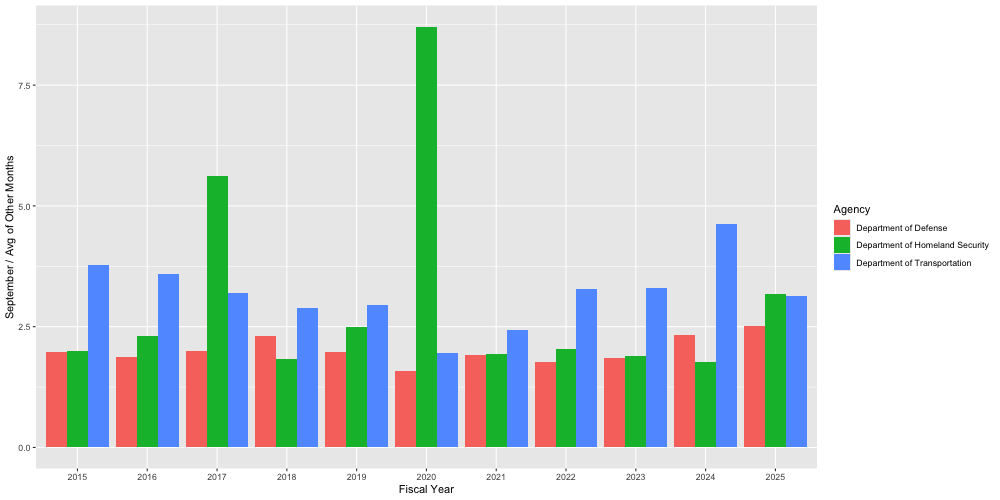

In [73]:
%%R -w 1000 -h 500

ggplot(sept_compare, aes(
  x = factor(fiscal_year),
  y = ratio,
  fill = agency
)) +
  geom_col(position = "dodge") +
  labs(
    x = "Fiscal Year",
    y = "September / Avg of Other Months",
    fill = "Agency"
  )

There is a clear limitation in using API to collect spending details, so I paused going forward on this avenue to pivot to do something similar.<br>
Inspiration: How Much Does America Spend? by NYT, March last year<br>
https://www.nytimes.com/2025/03/31/briefing/us-federal-government-spending-doge.html

## 1-1. Recreate the first chart
data from https://www.hamiltonproject.org/data/tracking-federal-expenditures-in-real-time/

In [ ]:
# read csv
df = pd.read_csv('chart_1/all_outlays_2026-03-22.csv')

# select rows of total only: what is needed is not individual spending of an agency per day; —> this is row filtering, not column filtering
df_total = df[df['transaction_catg_renamed'] == 'Total'].copy()

# astype from numbers to datetime
df_total['date'] = pd.to_datetime(df_total['date'])

# filter based on year: 2022~2026, month: 1~3, and date: filter out days > 19 if month = 3
# tilda ~ is a negative operator, therefore the third line filters out later days than march 19
filtered = df_total[
    (df_total['date'].dt.year >= 2022) & 
    (df_total['date'].dt.month <= 3) &
    ~((df_total['date'].dt.month == 3) & (df_total['date'].dt.day > 19))
]

# add year column; .astype(str) to pass year as categorial
filtered['year'] = filtered['date'].dt.year.astype(str)

# month_day column for x axis
filtered['month_day'] = filtered['date'].dt.strftime('%m-%d')

# reindex
filtered = filtered.reset_index(drop=True)

# filter based on columns to plot
final = filtered[['year', 'month_day', 'Cumulative year-to-date']]

# pivot to wide form
# reset_index pulls 'month_day' column from index back into column so when you pivot in pandas .reset_index() is almost always necessary
# while in R other columns that are not appointed for pivot method acts as id columns therefore not requires explicit index
final = final.pivot(index='month_day', columns='year', values='Cumulative year-to-date').reset_index()
final.columns.name = None

final

/var/folders/95/bxjxx49546qcwjnhzfnslm9r0000gn/T/ipykernel_1472/1772838066.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['year'] = filtered['date'].dt.year.astype(str)
/var/folders/95/bxjxx49546qcwjnhzfnslm9r0000gn/T/ipykernel_1472/1772838066.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['month_day'] = filtered['date'].dt.strftime('%m-%d')


,month_day,2022,2023,2024,2025,2026
0,01-01,NaN,NaN,0.000,0.000,0.000
1,01-02,0.000,0.000,88.383,82.055,119.852
2,01-03,93.225,109.755,125.466,125.383,NaN
3,01-04,111.349,128.943,141.254,NaN,NaN
4,01-05,126.869,149.107,159.343,NaN,134.927
...,...,...,...,...,...,...
74,03-15,1446.838,1608.962,1610.733,NaN,NaN
75,03-16,1495.049,1624.541,NaN,NaN,1780.271
76,03-17,1511.935,1642.786,NaN,1701.983,1796.183
77,03-18,1529.967,NaN,1627.512,1716.665,1854.037


/var/folders/95/bxjxx49546qcwjnhzfnslm9r0000gn/T/ipykernel_1472/2115107798.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  final = final.fillna(method='ffill')


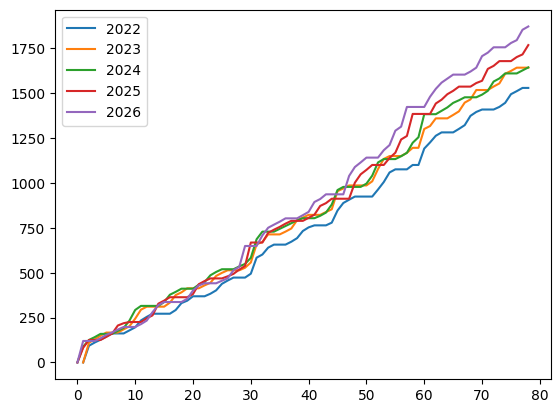

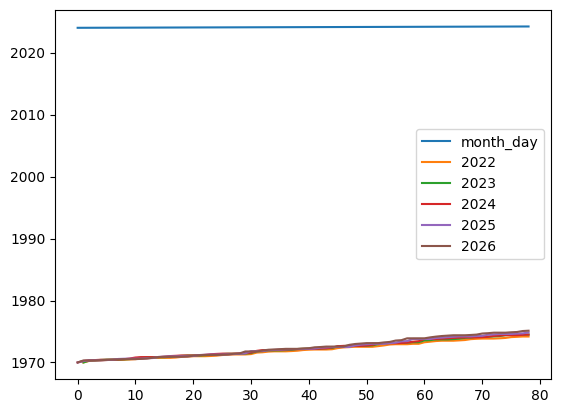

In [ ]:
# plot it
import matplotlib.pyplot as plt
final.plot(kind='line')

# too many breaks due to NaN values coming from non-business days (weekends)
# fill NaN with the previous value, for example, saturday copies friday's value
final = final.fillna(method='ffill')

# aribtrary year is added to month_day column so that month_day can be read as time and x axis can display only months (Jan, Feb, Mar)
# without this, x axis now displays ticks like this: 01-01, 01-10,...; but if it is perceived as time type, i can customize it to only show months
final['month_day'] = pd.to_datetime('2024-' + final['month_day'])

# plot it again
final.plot(kind='line')

# now it looks fine so save as csv
final.to_csv('chart_1/cumulative_spending_by_year.csv', index=False)

In [119]:
final

year,month_day,2022,2023,2024,2025,2026
0,01-01,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00
1,01-02,0.000000e+00,0.000000e+00,8.838300e-10,8.205500e-10,1.198520e-09
2,01-03,9.322500e-10,1.097550e-09,1.254660e-09,1.253830e-09,1.198520e-09
3,01-04,1.113490e-09,1.289430e-09,1.412540e-09,1.253830e-09,1.198520e-09
4,01-05,1.268690e-09,1.491070e-09,1.593430e-09,1.253830e-09,1.349270e-09
...,...,...,...,...,...,...
74,03-15,1.446838e-08,1.608962e-08,1.610733e-08,1.679340e-08,1.756321e-08
75,03-16,1.495049e-08,1.624541e-08,1.610733e-08,1.679340e-08,1.780271e-08
76,03-17,1.511935e-08,1.642786e-08,1.610733e-08,1.701983e-08,1.796183e-08
77,03-18,1.529967e-08,1.642786e-08,1.627512e-08,1.716665e-08,1.854037e-08


## 1-2. Apply CPI
data from Federal Reserve Bank of St. Louis (FRED) https://fred.stlouisfed.org/series/CPIAUCSL

In [113]:
# read spending csv
df = pd.read_csv('chart_1/all_outlays_2026-03-22.csv')
df_total = df[df['transaction_catg_renamed'] == 'Total'].copy()     # total = daily sum of spending of all agencies 
df_total['date'] = pd.to_datetime(df_total['date'])

# read CPI csv
cpi = pd.read_csv('chart_1/CPIAUCSL.csv')
cpi['observation_date'] = pd.to_datetime(cpi['observation_date'])
cpi.columns = ['date', 'cpi']

# month_start column added as CPI data comes on a monthly basis
df_total['month_start'] = df_total['date'].dt.to_period('M').dt.to_timestamp()

# merge uses column values as index while join uses index
# left(right)_on for index, how for basing left(or right) column, and suffix to distinguish columns that shares the name
# no need to filter 'cpi' column based on needed months before merging because how='left' designates left column as the default, removing right column's rows after unsuccessfully matching values
df_merged = df_total.merge(cpi, left_on='month_start', right_on='date', how='left', suffixes=('', '_cpi'))

# set 2022-01 the base point to detrend inflation
# df['name'] returns a series so .value (attribute) is needed to pull actual value out of it
base_cpi = cpi[cpi['date'] == '2022-01-01']['cpi'].values[0]

# calculation actual spending w/ inflation noise
# inflation rate =  comparing year cpi / base year cpi, so real spending = comparing year spending multiply by inflation rate
df_merged['real_cumulative'] = df_merged['Cumulative year-to-date'] / (df_merged['cpi'] / base_cpi)

# filter based on after 2022 + Jan~Mar + til Mar 19th
# last condition rid df of march 2026 rows cause the latest cpi is the previous month's and march of 2026 data becomes pointless
filtered = df_merged[
    (df_merged['date'].dt.year >= 2022) & 
    (df_merged['date'].dt.month <= 3) &
    ~((df_merged['date'].dt.month == 3) & (df_merged['date'].dt.day > 19)) &  
    ~((df_merged['date'].dt.year == 2026) & (df_merged['date'].dt.month == 3)) 
]


# refine the data for making a datawrapper graph
filtered['year'] = filtered['date'].dt.year.astype(str)
filtered['month_day'] = filtered['date'].dt.strftime('2022-%m-%d')

# real expenditures privot from long to wide (for datawrapper)
# the last line here switchs 2026march values back to before being filled using .fillna(method='ffill') because they are natural NaN's caused by lack of CPI for march 2026 (we're in the middle of march 2026 at this moment)
real = filtered.pivot(index='month_day', columns='year', values='real_cumulative').reset_index()
real.columns.name = None
real = real.fillna(method='ffill')      # fill up weekends NaN values with the previous data point       
real.loc[real['month_day'].str.contains('-03-'), '2026'] = None     # .contains() returns boolean   

# save as csv
real.to_csv('chart_1/real_spending.csv', index=False)

/var/folders/95/bxjxx49546qcwjnhzfnslm9r0000gn/T/ipykernel_23428/149917021.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['year'] = filtered['date'].dt.year.astype(str)
/var/folders/95/bxjxx49546qcwjnhzfnslm9r0000gn/T/ipykernel_23428/149917021.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['month_day'] = filtered['date'].dt.strftime('2022-%m-%d')
/var/folders/95/bxjxx49546qcwjnhzfnslm9r0000gn/T/ipykernel_23428/149917021.py:45: FutureWarning: DataFrame.fillna with 'method' is de

## Recreate the second chart
data from https://cbo.gov/publication/21728 and https://www.cbo.gov/data/budget-economic-data (Historical Budget Data → Feb 2026)

In [ ]:
xl = pd.ExcelFile('use-it-or-lose-it/historical_debt.xls')      # pd.ExcelFile used when checking multiple sheet names in a file only
xl.sheet_names

FileNotFoundError: [Errno 2] No such file or directory: 'use-it-or-lose-it/historical_debt.xls'

### Old version excel file (.xls) cannot be read by pandas.
- `.xls` : old version used between 1997~2003, a binary form created by MS.
- `.xlsx` : used since 2007. internally constructed with ZIP + XML 

pandas uses <b>openpyxl</b> as default, which can't read `.xls` file. so need to assign <b>xlrd</b> explicitly.

In [35]:
import pandas as pd

# testing with engine='xlrd'
df = pd.read_excel('chart_2/historical_debt.xls', engine='xlrd', header=None)       # header=None means don't pass the first row as column names

df.shape        # (216,6)
df.head(10).to_string()         # to_string() prevents it from being truncated when there are too many columns

'                                                                0                                 1                                  2                               3   4                                                                                                                                       5\n0                                                             NaN                               NaN                                NaN                             NaN NaN                                                                                                                                     NaN\n1  Historical Data on Federal Debt Held by the Public (July 2010)                               NaN                                NaN                             NaN NaN                                                                                                                                     NaN\n2                                                             NaN          

In [49]:
# actually reading!
df = pd.read_excel('chart_2/historical_debt.xls', engine='xlrd', header=None)

# starting from row 5 where actual data starts, select col 0(year) and col 1(debt % GDP) only
df_clean = df.iloc[5:, [0, 1]].copy()


# name columns
df_clean.columns = ['year', 'debt_pct_gdp']

# print() used to see the results of both lines at the same time
print(df_clean)     # index starts at 5 and data runs until 2000
print(df_clean.dtypes)      # numbers are object type

     year debt_pct_gdp
5    1790         29.6
6    1791         29.2
7    1792           28
8    1793         24.4
9    1794         21.8
..    ...          ...
211  1996         47.9
212  1997         45.3
213  1998         42.3
214  1999         38.6
215  2000         34.5

[211 rows x 2 columns]
year            object
debt_pct_gdp    object
dtype: object


In [50]:
# reset index and astype integer
df_clean = df_clean.reset_index(drop=True)      # drop=True drops the old index instead of integrating it into df as a column
df_clean['debt_pct_gdp'] = df_clean['debt_pct_gdp'].astype(float)
df_clean['year'] = df_clean['year'].astype(int)

# print() used to see the results of both lines at the same time
print(df_clean)
print(df_clean.dtypes)

     year  debt_pct_gdp
0    1790          29.6
1    1791          29.2
2    1792          28.0
3    1793          24.4
4    1794          21.8
..    ...           ...
206  1996          47.9
207  1997          45.3
208  1998          42.3
209  1999          38.6
210  2000          34.5

[211 rows x 2 columns]
year              int64
debt_pct_gdp    float64
dtype: object


In [51]:
df_clean

,year,debt_pct_gdp
0,1790,29.6
1,1791,29.2
2,1792,28.0
3,1793,24.4
4,1794,21.8
...,...,...
206,1996,47.9
207,1997,45.3
208,1998,42.3
209,1999,38.6


In [53]:
# filter 1900-1961 only; this will be put together with another file with data between 1962 thru 2025
df_pre1962 = df_clean.loc[(df_clean['year'] >= 1900) & (df_clean['year'] <= 1962)]
df_pre1962 = df_pre1962.reset_index(drop=True)      # reindexing

df_pre1962

,year,debt_pct_gdp
0,1900,6.6
1,1901,5.7
2,1902,5.4
3,1903,5.0
4,1904,4.7
...,...,...
58,1958,49.5
59,1959,47.0
60,1960,44.8
61,1961,44.6


In [54]:
# read the second file
df = pd.read_excel('chart_2/51134-2026-02-Historical-Budget-Data.xlsx', sheet_name='1a. Rev, Outlays, Surplus (GDP)')

# again, select needed rows and column only
df_clean = df.iloc[9:, [0, 7]].copy()

# assign column names
df_clean.columns = ['year', 'debt_pct_gdp']

# reindexing and astyping
df_clean = df_clean.dropna()     # from time to time pandas brings empty rows at the bottom even if all values are there in the actual table
df_clean['year'] = df_clean['year'].astype(int)
df_clean['debt_pct_gdp'] = df_clean['debt_pct_gdp'].astype(float)
df_clean = df_clean.reset_index(drop=True)

# just rename
df_post1962 = df_clean

df_post1962.to_string()
df_post1962.head(5)
df_post1962.tail(5)

,year,debt_pct_gdp
58,2021,96.702
59,2022,94.868
60,2023,95.758
61,2024,97.401
62,2025,99.375


In [55]:
# join them by .concat(); .merge() and .join() are for crosswise amalgamation
df_1900_to_2025 = pd.concat([df_pre1962, df_post1962])

# export as csv
df_1900_to_2025.to_csv('chart_2/df_1900_to_2025.csv', index=False)


## Recreate the third chart
data from https://fiscaldata.treasury.gov/datasets/monthly-treasury-statement/

| Division | Record Type Code | Definition |
|---|---|---|
| RSG | Receipt Source Group | Revenue(e.g., taxes) |
| F | Function | Outlays (Defense, Social Security, etc.) |
| SL | Section Line | Section header / Total amount |

In [27]:
# read dsv
df = pd.read_csv('MTS_RcptSrcOutlyFcn_20150331_20260228.csv')

# this is a cumulative data, consequently FY2025's last month—September 2025—is the total spending of the correspoding year; filtering F types (Outlays) only
fy2025 = df[(df['Record Date'] == '2025-09-30') & (df['Record Type Code'] == 'F')]

# select needed columns only: Classification is each category of F while Current FYTD is a cumulative spending of each category for FY2025
result = fy2025[['Classification Description', 'Current FYTD Receipt or Outlay Amount']].copy()
result.columns = ['category', 'amount']         # rename

# sort values!
result = result.sort_values('amount', ascending=False)

# ratio to total
result['percentage'] = (result['amount'].sum() / result['amount'] * 100).round(1)

# unit = one billion
result['amount_billions'] = (result['amount'] / 1e9)

result

FileNotFoundError: [Errno 2] No such file or directory: 'MTS_RcptSrcOutlyFcn_20150331_20260228.csv'

In [28]:
# reconstrut result according to the NYT chart: remove rows with negative numbers, which means revenue other than spending and merge some rows
# no negative spending
result = result[result['amount_billions'] > 0]

# pre-work to create another column named 'nyt_category'
# following an nyt style, mapping categories in a dictionary form
category_mapping = {
    'Social Security': 'Social Security',
    'Medicare': 'Medicare',
    'National Defense': 'Defense',
    'Health': 'Other health services (includes Medicaid)',
    'Net Interest': 'Interest payments',
    'Income Security': 'Income security (includes welfare programs)',
    'Veterans Benefits and Services': 'Veterans benefits and services',
    'Education, Training, Employment, and Social Services': 'Education',
    'Transportation': 'Transportation'
}

# other category: categories to be lumped together
other_categories = [
    'General Science, Space, and Technology',
    'Energy',
    'Natural Resources and Environment',
    'Agriculture',
    'Commerce and Housing Credit',
    'Community and Regional Development',
    'International Affairs',
    'Administration of Justice',
    'General Government'
]

# a function to help assign a nyt style category name to each row by applying the two variables above
# you have to know that you need to use .apply() here in order to use the parameter 'row'
def assign_category(row):
    if row['category'] in category_mapping:
        return category_mapping[row['category']]
    elif row['category'] in other_categories:
        return 'other'
    else:
        return None

result['nyt_category'] = result.apply(assign_category, axis=1)      # apply is so much easier than for-loop, saving us from creating an empty list, appending return values and ultimately integrating that list to the original dataframe

# remove None rows
result = result[result['nyt_category'].notna()]

# sum by nyt category
final = result.groupby('nyt_category')['amount_billions'].sum().reset_index()

# calculate ratio again
total = final['amount_billions'].sum()
final['percentage'] = (final['amount_billions'] / total * 100).round(1)

# sort by percentage in a descending order
final = final.sort_values('percentage', ascending=False)
final = final.reset_index(drop=True)

final
total   # 7188.818952527781 means 7.18 trillions

# save as csv w/ amount_billions
final[['nyt_category', 'percentage']].to_csv('fy2025_spending_nyt_style.csv', index=False)

NameError: name 'result' is not defined

## Recreate the fourth chart
unfortunately, the fourth chart pauses here until new data emerges. the nyt used the latest set of data on federal personnel spending, which is fy2022. the congressional budget office (CBO) intermittenly, seemingly every five year, publishes a report that analyzes federal employees compensation, from which the original data comes from.<br>
the latest data published in apr, 2024 can be found here: https://www.cbo.gov/topics/employment-and-labor-markets/federal-personnel